# H13 promoter/intergenic matrix inspection

Goal: inspect the two new H13 motif matrices before building the Elastic Net / enrichment pipeline.


In [7]:
!pip install matplotlib

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROMOTER_FILE = Path("../promoter_TF_distance_weighted_H13_human_promoters_power_x1_d500.csv")
INTERGENIC_FILE = Path("../promoter_TF_distance_weighted_H13_human_intergenic_power_x1_d500.csv")

PROMOTER_FILE.exists(), INTERGENIC_FILE.exists()


(True, True)

In [9]:
prom_head = pd.read_csv(PROMOTER_FILE, nrows=5)
inter_head = pd.read_csv(INTERGENIC_FILE, nrows=5)

print("Promoter preview shape:", prom_head.shape)
display(prom_head.head())

print("Intergenic preview shape:", inter_head.shape)
display(inter_head.head())


Promoter preview shape: (5, 652)


,promoter_id,AHCTF1.H13CORE.0.B.B,AHR.H13CORE.0.P.B,ALX1.H13CORE.0.SM.B,ANDR.H13CORE.1.S.C,ANDR.H13CORE.2.P.B,AP2A.H13CORE.0.PSM.A,ARNT.H13CORE.0.P.B,ARNT2.H13CORE.0.P.B,ATF1.H13CORE.1.P.B,...,ZSC23.H13CORE.0.M.C,ZSC29.H13CORE.0.P.B,ZSC29.H13CORE.1.M.C,ZSC31.H13CORE.0.P.C,ZSCA1.H13CORE.0.SM.B,ZSCAN12.H13CORE.0.P.B,ZSCAN2.H13CORE.0.PG.A,ZSCAN25.H13CORE.0.PSG.A,ZXDA.H13CORE.0.PSI.A,ZXDC.H13CORE.0.PI.A
0,gene-OR4F16|OR4F16|chr1:107876-117877|-,302.332236,17.941461,34.013831,164.797344,335.398194,3.790701,48.721730,144.299281,18.516320,...,4.839252,53.633622,12.155462,35.184567,2.758547,138.829016,0.365287,7.726213,36.682951,15.609821
1,gene-SAMD11|SAMD11|chr1:348565-358566|+,19.340017,106.962620,0.704667,67.601283,58.273912,126.511248,105.848932,225.198969,111.177175,...,0.330642,136.069577,2.670962,179.830138,9.959176,266.290223,0.000000,95.240338,400.288574,121.867755
2,gene-NOC2L|NOC2L|chr1:383040-393041|-,43.043277,110.551691,0.630066,64.879750,106.249774,163.746683,107.512710,195.744209,120.124106,...,4.461482,136.457242,2.299665,180.647134,3.405136,276.570075,0.246302,67.752125,311.213273,105.019855
3,gene-KLHL17|KLHL17|chr1:384373-394374|+,24.091429,99.126770,1.826247,59.478485,72.509248,194.859057,106.007893,190.749799,121.381597,...,2.861341,151.597975,2.205529,204.674574,3.148192,278.045765,0.380648,68.033367,350.141791,129.096476
4,gene-PLEKHN1|PLEKHN1|chr1:390192-400193|+,28.317637,139.136414,5.733277,80.299276,137.485214,166.712558,175.525151,308.016942,80.768011,...,4.770543,160.319357,12.315560,193.470044,28.377810,255.382943,0.246302,89.286750,318.594021,135.428670


Intergenic preview shape: (5, 652)


,promoter_id,AHCTF1.H13CORE.0.B.B,AHR.H13CORE.0.P.B,ALX1.H13CORE.0.SM.B,ANDR.H13CORE.1.S.C,ANDR.H13CORE.2.P.B,AP2A.H13CORE.0.PSM.A,ARNT.H13CORE.0.P.B,ARNT2.H13CORE.0.P.B,ATF1.H13CORE.1.P.B,...,ZSC23.H13CORE.0.M.C,ZSC29.H13CORE.0.P.B,ZSC29.H13CORE.1.M.C,ZSC31.H13CORE.0.P.C,ZSCA1.H13CORE.0.SM.B,ZSCAN12.H13CORE.0.P.B,ZSCAN2.H13CORE.0.PG.A,ZSCAN25.H13CORE.0.PSG.A,ZXDA.H13CORE.0.PSI.A,ZXDC.H13CORE.0.PI.A
0,chr1:316720-326720,316.226463,44.409154,41.641048,101.421288,297.191814,19.193454,52.858850,163.070528,31.462869,...,5.200775,40.789557,8.673234,66.010690,4.894463,169.089859,0.0,41.846963,78.259130,31.350350
1,chr1:430252-440252,59.854380,73.976965,6.358749,60.720569,124.065969,103.307985,78.434293,213.703053,92.517493,...,2.076244,91.633290,1.519970,167.914141,12.109655,310.149758,0.0,120.256940,339.540111,107.213793
2,chr1:794097-804097,167.838635,108.989561,18.522978,58.369318,263.861656,44.528687,96.808322,261.191185,78.718146,...,2.541032,60.904225,8.853590,112.416145,15.943847,208.621756,0.0,62.867689,164.552040,59.864199
3,chr1:805756-815756,143.045976,78.858657,14.279440,54.885674,156.622881,59.082686,74.210017,220.839509,96.598795,...,10.111368,87.979054,3.582691,132.772655,3.050342,196.311311,0.0,64.770781,260.135134,78.486970
4,chr1:1019369-1029369,199.256162,83.287923,15.300426,47.162150,242.564876,35.242409,78.326811,182.417485,81.470554,...,1.159989,91.630385,10.156500,119.317282,10.217011,240.982179,0.0,44.714192,154.214204,78.097097


In [10]:
prom_cols = pd.read_csv(PROMOTER_FILE, nrows=0).columns
inter_cols = pd.read_csv(INTERGENIC_FILE, nrows=0).columns

print("Promoter columns:", len(prom_cols))
print("Intergenic columns:", len(inter_cols))
print("Columns identical:", list(prom_cols) == list(inter_cols))

print("\nFirst 10 columns:")
print(prom_cols[:10].tolist())

print("\nLast 10 columns:")
print(prom_cols[-10:].tolist())


Promoter columns: 652
Intergenic columns: 652
Columns identical: True

First 10 columns:
['promoter_id', 'AHCTF1.H13CORE.0.B.B', 'AHR.H13CORE.0.P.B', 'ALX1.H13CORE.0.SM.B', 'ANDR.H13CORE.1.S.C', 'ANDR.H13CORE.2.P.B', 'AP2A.H13CORE.0.PSM.A', 'ARNT.H13CORE.0.P.B', 'ARNT2.H13CORE.0.P.B', 'ATF1.H13CORE.1.P.B']

Last 10 columns:
['ZSC23.H13CORE.0.M.C', 'ZSC29.H13CORE.0.P.B', 'ZSC29.H13CORE.1.M.C', 'ZSC31.H13CORE.0.P.C', 'ZSCA1.H13CORE.0.SM.B', 'ZSCAN12.H13CORE.0.P.B', 'ZSCAN2.H13CORE.0.PG.A', 'ZSCAN25.H13CORE.0.PSG.A', 'ZXDA.H13CORE.0.PSI.A', 'ZXDC.H13CORE.0.PI.A']


In [11]:
keywords = ["tpm", "expr", "expression", "log", "rna", "count", "target"]

for name, cols in [("promoter", prom_cols), ("intergenic", inter_cols)]:
    hits = [c for c in cols if any(k in c.lower() for k in keywords)]
    print(name, "possible expression columns:", hits if hits else "NONE")


promoter possible expression columns: NONE
intergenic possible expression columns: NONE


In [12]:
for f in [PROMOTER_FILE, INTERGENIC_FILE]:
    n_rows = sum(1 for _ in open(f)) - 1
    print(f.name, "rows:", n_rows)


promoter_TF_distance_weighted_H13_human_promoters_power_x1_d500.csv rows: 20090
promoter_TF_distance_weighted_H13_human_intergenic_power_x1_d500.csv rows: 20000


In [13]:
prom = pd.read_csv(PROMOTER_FILE)
inter = pd.read_csv(INTERGENIC_FILE)

motif_cols = [c for c in prom.columns if c != "promoter_id"]

summary = pd.DataFrame({
    "dataset": ["promoter", "intergenic"],
    "rows": [len(prom), len(inter)],
    "columns": [prom.shape[1], inter.shape[1]],
    "motif_columns": [len(motif_cols), len(motif_cols)],
    "missing_values": [prom[motif_cols].isna().sum().sum(), inter[motif_cols].isna().sum().sum()],
    "negative_values": [(prom[motif_cols] < 0).sum().sum(), (inter[motif_cols] < 0).sum().sum()],
    "all_zero_rows": [
        (prom[motif_cols].sum(axis=1) == 0).sum(),
        (inter[motif_cols].sum(axis=1) == 0).sum()
    ],
    "duplicate_ids": [
        prom["promoter_id"].duplicated().sum(),
        inter["promoter_id"].duplicated().sum()
    ]
})

display(summary)


,dataset,rows,columns,motif_columns,missing_values,negative_values,all_zero_rows,duplicate_ids
0,promoter,20090,652,651,0,0,1,0
1,intergenic,20000,652,651,0,0,0,0


In [14]:
prom["motif_sum"] = prom[motif_cols].sum(axis=1)
inter["motif_sum"] = inter[motif_cols].sum(axis=1)

display(pd.DataFrame({
    "promoter": prom["motif_sum"].describe(),
    "intergenic": inter["motif_sum"].describe()
}))


/tmp/ipykernel_2075/874187856.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  prom["motif_sum"] = prom[motif_cols].sum(axis=1)
/tmp/ipykernel_2075/874187856.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  inter["motif_sum"] = inter[motif_cols].sum(axis=1)


,promoter,intergenic
count,20090.000000,20000.000000
mean,54973.660651,48986.993052
std,7294.633741,8797.450495
min,0.000000,32290.545344
25%,49705.420391,45172.653873
50%,53895.114133,47263.381781
75%,58917.620832,50545.417957
max,164850.358944,221842.954752


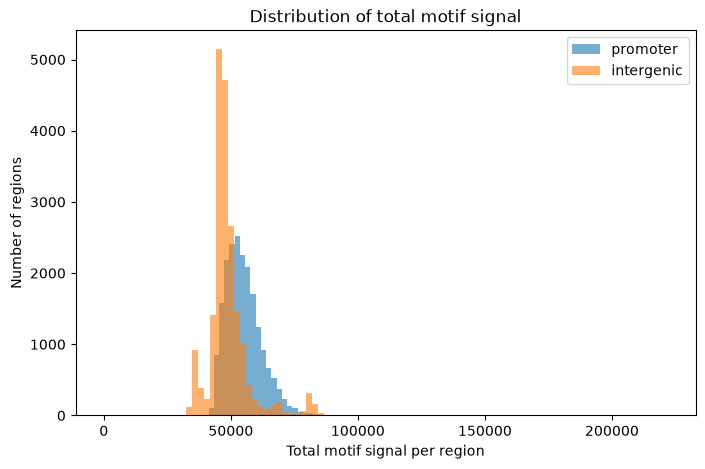

In [15]:
plt.figure(figsize=(8, 5))
plt.hist(prom["motif_sum"], bins=80, alpha=0.6, label="promoter")
plt.hist(inter["motif_sum"], bins=80, alpha=0.6, label="intergenic")
plt.xlabel("Total motif signal per region")
plt.ylabel("Number of regions")
plt.legend()
plt.title("Distribution of total motif signal")
plt.show()


In [16]:
top_prom = prom[["promoter_id", "motif_sum"]].sort_values("motif_sum", ascending=False).head(10)
top_inter = inter[["promoter_id", "motif_sum"]].sort_values("motif_sum", ascending=False).head(10)

print("Top promoter regions by motif sum")
display(top_prom)

print("Top intergenic regions by motif sum")
display(top_inter)


Top promoter regions by motif sum


,promoter_id,motif_sum
18412,gene-CHRNA4|CHRNA4|chr20:65162971-65172972|-,164850.358944
12638,gene-ZNF605|ZNF605|chr12:133008677-133018678|-,122331.499769
19138,gene-SHOX|SHOX|chrX:459174-469175|+,122089.776672
19990,gene-SHOX-2|SHOX|chrY:473001-483002|+,120593.362092
16493,gene-PLPP2|PLPP2|chr19:237447-247448|-,117002.900986
7159,gene-SLC29A4|SLC29A4|chr7:5395702-5405703|+,115664.915427
16565,gene-BTBD2|BTBD2|chr19:1983204-1993205|-,113916.790543
30,gene-TMEM88B|TMEM88B|chr1:852799-862800|+,112624.116137
17626,gene-LRRC4B|LRRC4B|chr19:53652263-53662264|-,110987.005297
19139,gene-CRLF2|CRLF2|chrX:1053463-1063464|-,110854.159955


Top intergenic regions by motif sum


,promoter_id,motif_sum
19508,chrY:326145-336145,221842.954752
19664,chrY:16112217-16122217,138154.600000
18100,chr22:34850002-34860002,134822.655453
12929,chr13:8098848-8108848,131015.689269
12935,chr13:9085218-9095218,131015.689269
12918,chr13:6595808-6605808,131015.689269
12916,chr13:6267018-6277018,131015.689269
12928,chr13:7817028-7827028,131015.689269
12914,chr13:5797318-5807318,131015.689269
14390,chr15:4362848-4372848,127563.123059


In [17]:
motif_means = pd.DataFrame({
    "motif": motif_cols,
    "promoter_mean": prom[motif_cols].mean().values,
    "intergenic_mean": inter[motif_cols].mean().values
})

motif_means["intergenic_minus_promoter"] = motif_means["intergenic_mean"] - motif_means["promoter_mean"]
motif_means["intergenic_over_promoter"] = motif_means["intergenic_mean"] / motif_means["promoter_mean"].replace(0, np.nan)

display(motif_means.sort_values("intergenic_minus_promoter", ascending=False).head(20))
display(motif_means.sort_values("intergenic_minus_promoter", ascending=True).head(20))


,motif,promoter_mean,intergenic_mean,intergenic_minus_promoter,intergenic_over_promoter
82,HMGA1.H13CORE.0.P.B,184.739188,391.407021,206.667834,2.118701
481,ZN671.H13CORE.0.P.C,116.140577,309.207236,193.066659,2.662353
466,ZN613.H13CORE.0.P.C,518.273522,707.436035,189.162513,1.364986
145,NKX61.H13CORE.0.PS.A,165.673806,337.493286,171.819480,2.037095
306,ZFP82.H13CORE.0.P.C,133.652436,299.578843,165.926407,2.241477
585,ZNF618.H13CORE.0.G.B,195.454244,354.069885,158.615641,1.811523
111,LMX1B.H13CORE.0.P.C,216.294284,358.793849,142.499564,1.658823
237,TCF20.H13CORE.0.B.B,189.939122,320.285237,130.346114,1.686252
214,SOX2.H13CORE.3.S.B,55.176788,169.687447,114.510659,3.075341
559,ZNF35.H13CORE.0.P.C,247.493478,359.261000,111.767522,1.451598


,motif,promoter_mean,intergenic_mean,intergenic_minus_promoter,intergenic_over_promoter
107,KMT2A.H13CORE.0.P.B,397.557427,27.385242,-370.172185,0.068884
105,KLF16.H13CORE.1.P.B,461.382401,101.546958,-359.835444,0.220093
115,MBD3.H13CORE.0.P.B,525.949731,197.571558,-328.378173,0.375647
9,ATMIN.H13CORE.0.P.B,490.991159,188.611719,-302.379440,0.384145
166,PATZ1.H13CORE.0.P.B,458.112088,188.567989,-269.544099,0.411620
434,ZN543.H13CORE.0.P.C,344.425897,79.342116,-265.083781,0.230360
391,ZN383.H13CORE.0.P.C,366.506955,156.105434,-210.401521,0.425928
221,SP5.H13CORE.1.P.B,296.731601,120.804494,-175.927107,0.407117
341,ZN180.H13CORE.0.P.C,229.110401,60.798412,-168.311989,0.265367
23,CPXCR1.H13CORE.0.P.C,249.099789,81.967120,-167.132669,0.329053


## Conclusion notes

If no TPM/expression column appears above, these two files are motif-only matrices.

Next step: locate the H13 TPM/expression table or inspect the old notebook to see how TPM was merged.


In [18]:
import pandas as pd
from pathlib import Path

old_file = Path(
    "/mnt/c/disk_D/MASTER/promoter_motif_expression/data/processed/motif_matrices/promoter_motif_M_woTFTPM0.csv"
)

new_file = Path(
    "/mnt/c/disk_D/MASTER/promoter_motif_expression_new_matrix/promoter_TF_distance_weighted_H13_human_promoters_power_x1_d500.csv"
)

old_df = pd.read_csv(old_file)
new_df = pd.read_csv(new_file)

print("Old shape:", old_df.shape)
print("New shape:", new_df.shape)

Old shape: (20007, 512)
New shape: (20090, 652)


In [19]:
old_id_col = old_df.columns[0]
old_tpm_col = old_df.columns[-1]

print("Old ID column:", old_id_col)
print("Old TPM column:", old_tpm_col)

print("\nOld first IDs:")
display(old_df[old_id_col].head())

print("\nOld TPM preview:")
display(old_df[[old_id_col, old_tpm_col]].head())

Old ID column: promoter_id
Old TPM column: log2_TPM_plus1

Old first IDs:


0      gene-OR4F16|OR4F16|NC_060925.1:112376-113377|-
1      gene-SAMD11|SAMD11|NC_060925.1:353065-354066|+
2        gene-NOC2L|NOC2L|NC_060925.1:387540-388541|-
3      gene-KLHL17|KLHL17|NC_060925.1:388873-389874|+
4    gene-PLEKHN1|PLEKHN1|NC_060925.1:394692-395693|+
Name: promoter_id, dtype: str


Old TPM preview:


,promoter_id,log2_TPM_plus1
0,gene-OR4F16|OR4F16|NC_060925.1:112376-113377|-,0.150560
1,gene-SAMD11|SAMD11|NC_060925.1:353065-354066|+,5.361768
2,gene-NOC2L|NOC2L|NC_060925.1:387540-388541|-,7.795195
3,gene-KLHL17|KLHL17|NC_060925.1:388873-389874|+,4.693766
4,gene-PLEKHN1|PLEKHN1|NC_060925.1:394692-395693|+,0.000000


In [20]:
old_tpm = old_df[[old_id_col, old_tpm_col]].copy()
old_tpm = old_tpm.rename(columns={old_id_col: "promoter_id"})

merged_df = new_df.merge(old_tpm, on="promoter_id", how="left")

print("New rows:", len(new_df))
print("Merged rows:", len(merged_df))
print("Missing TPM:", merged_df[old_tpm_col].isna().sum())
print("Rows with TPM:", merged_df[old_tpm_col].notna().sum())

New rows: 20090
Merged rows: 20090
Missing TPM: 20090
Rows with TPM: 0


In [21]:
old_id_col = old_df.columns[0]

print("Old ID column:", old_id_col)
display(old_df[old_id_col].head(10))

print("New promoter_id:")
display(new_df["promoter_id"].head(10))

Old ID column: promoter_id


0      gene-OR4F16|OR4F16|NC_060925.1:112376-113377|-
1      gene-SAMD11|SAMD11|NC_060925.1:353065-354066|+
2        gene-NOC2L|NOC2L|NC_060925.1:387540-388541|-
3      gene-KLHL17|KLHL17|NC_060925.1:388873-389874|+
4    gene-PLEKHN1|PLEKHN1|NC_060925.1:394692-395693|+
5        gene-PERM1|PERM1|NC_060925.1:411432-412433|-
6          gene-HES4|HES4|NC_060925.1:429751-430752|-
7        gene-ISG15|ISG15|NC_060925.1:443127-444128|+
8          gene-AGRN|AGRN|NC_060925.1:449746-450747|+
9      gene-RNF223|RNF223|NC_060925.1:503899-504900|-
Name: promoter_id, dtype: str

New promoter_id:


0      gene-OR4F16|OR4F16|chr1:107876-117877|-
1      gene-SAMD11|SAMD11|chr1:348565-358566|+
2        gene-NOC2L|NOC2L|chr1:383040-393041|-
3      gene-KLHL17|KLHL17|chr1:384373-394374|+
4    gene-PLEKHN1|PLEKHN1|chr1:390192-400193|+
5        gene-PERM1|PERM1|chr1:406932-416933|-
6          gene-HES4|HES4|chr1:425251-435252|-
7        gene-ISG15|ISG15|chr1:438627-448628|+
8          gene-AGRN|AGRN|chr1:445246-455247|+
9      gene-RNF223|RNF223|chr1:499399-509400|-
Name: promoter_id, dtype: str

In [22]:
old_df["gene_symbol"] = old_df["promoter_id"].str.split("|").str[1]
new_df["gene_symbol"] = new_df["promoter_id"].str.split("|").str[1]

print(old_df["gene_symbol"].head())
print(new_df["gene_symbol"].head())

0     OR4F16
1     SAMD11
2      NOC2L
3     KLHL17
4    PLEKHN1
Name: gene_symbol, dtype: object
0     OR4F16
1     SAMD11
2      NOC2L
3     KLHL17
4    PLEKHN1
Name: gene_symbol, dtype: object


/tmp/ipykernel_2075/1807524299.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  old_df["gene_symbol"] = old_df["promoter_id"].str.split("|").str[1]
/tmp/ipykernel_2075/1807524299.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_df["gene_symbol"] = new_df["promoter_id"].str.split("|").str[1]


In [23]:
old_genes = set(old_df["gene_symbol"])
new_genes = set(new_df["gene_symbol"])

print("Old genes:", len(old_genes))
print("New genes:", len(new_genes))
print("Overlap:", len(old_genes & new_genes))

Old genes: 19988
New genes: 20071
Overlap: 19988


In [24]:
# Remove duplicate column names if gene_symbol was added more than once
old_df = old_df.loc[:, ~old_df.columns.duplicated()].copy()
new_df = new_df.loc[:, ~new_df.columns.duplicated()].copy()

# Recreate gene_symbol cleanly
old_df["gene_symbol"] = old_df["promoter_id"].astype(str).str.split("|").str[1]
new_df["gene_symbol"] = new_df["promoter_id"].astype(str).str.split("|").str[1]

print("old gene_symbol columns:", (old_df.columns == "gene_symbol").sum())
print("new gene_symbol columns:", (new_df.columns == "gene_symbol").sum())

old gene_symbol columns: 1
new gene_symbol columns: 1


In [25]:
tpm_col = old_df.columns[-2] if old_df.columns[-1] == "gene_symbol" else old_df.columns[-1]
print("TPM column:", tpm_col)

old_tpm = old_df[["gene_symbol", tpm_col]].copy()

# If duplicate gene symbols exist, keep first TPM per gene
old_tpm = old_tpm.drop_duplicates(subset="gene_symbol")

merged_df = new_df.merge(old_tpm, on="gene_symbol", how="left")

print("Total new promoter rows:", len(merged_df))
print("TPM matched:", merged_df[tpm_col].notna().sum())
print("Missing TPM:", merged_df[tpm_col].isna().sum())

display(merged_df[["promoter_id", "gene_symbol", tpm_col]].head())

TPM column: log2_TPM_plus1
Total new promoter rows: 20090
TPM matched: 20007
Missing TPM: 83


,promoter_id,gene_symbol,log2_TPM_plus1
0,gene-OR4F16|OR4F16|chr1:107876-117877|-,OR4F16,0.150560
1,gene-SAMD11|SAMD11|chr1:348565-358566|+,SAMD11,5.361768
2,gene-NOC2L|NOC2L|chr1:383040-393041|-,NOC2L,7.795195
3,gene-KLHL17|KLHL17|chr1:384373-394374|+,KLHL17,4.693766
4,gene-PLEKHN1|PLEKHN1|chr1:390192-400193|+,PLEKHN1,0.000000


In [27]:
from pathlib import Path

out_dir = Path("../data/processed")
out_dir.mkdir(parents=True, exist_ok=True)

merged_df.to_csv(
    out_dir / "H13_promoters_651motifs_with_TPM.csv",
    index=False
)

In [28]:
(out_dir / "H13_promoters_651motifs_with_TPM.csv").exists()

True

In [ ]:
print("kernel alive")

kernel alive


: 

In [2]:
print("hello")

hello
